# XGBoost 실험: 2023~2024 학습 → 2025 포스트시즌 예측 검증

**목표:** 2023~2024 일별 데이터로 XGBoost를 학습하고, 2025 시즌 실제 결과와 비교

**평가 방법:** 시즌 진행 시점(50% / 75% / 90% / 최종)별로 상위 5팀 예측 적중률 확인

In [1]:
import sys
sys.path.append("../../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
from src.utils.config import FEATURE_COLS

df = pd.read_csv("../../../data/modeling/train_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

train = df[df["season"].isin([2023, 2024])].copy()
test  = df[df["season"] == 2025].copy()

print(f"학습 데이터: {train.shape}  ({train['season'].unique()})")
print(f"테스트 데이터: {test.shape}   (2025)")
print(f"\n피처 수: {len(FEATURE_COLS)}개")
print(f"결측치 — 학습: {train[FEATURE_COLS].isna().sum().sum()}  테스트: {test[FEATURE_COLS].isna().sum().sum()}")

학습 데이터: (3300, 81)  ([2023 2024])
테스트 데이터: (1630, 81)   (2025)

피처 수: 44개
결측치 — 학습: 2466  테스트: 1246


In [3]:
X_train = train[FEATURE_COLS]
y_train = train["postseason"]

X_test = test[FEATURE_COLS]
y_test = test["postseason"]

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # 클래스 불균형 보정
    eval_metric="logloss",
    random_state=42,
)

model.fit(X_train, y_train)
print("학습 완료")

학습 완료


In [4]:
## 2025 전체 기간 예측 확률 부여
test = test.copy()
test["prob"] = model.predict_proba(X_test)[:, 1]

## 시점별 상위 5팀 예측 vs 실제 비교
checkpoints = {
    "50% 시점 (72경기)":  0.50,
    "75% 시점 (108경기)": 0.75,
    "90% 시점 (130경기)": 0.90,
    "최종 (144경기)":     1.00,
}

actual_top5 = set(test[test["postseason"] == 1]["team"].unique())
print(f"2025 실제 포스트시즌 팀: {sorted(actual_top5)}\n")
print(f"{'시점':<22} {'예측 상위 5팀':<35} {'적중'}")
print("-" * 65)

for label, ratio in checkpoints.items():
    snapshot = test[test["games_played_ratio"] <= ratio]
    latest = snapshot.sort_values("date").groupby("team").last().reset_index()
    top5_pred = set(latest.nlargest(5, "prob")["team"])
    hit = len(top5_pred & actual_top5)
    teams_str = ", ".join(sorted(top5_pred))
    print(f"{label:<22} {teams_str:<35} {hit}/5")

2025 실제 포스트시즌 팀: ['LG', 'NC', 'SSG', '삼성', '한화']

시점                     예측 상위 5팀                            적중
-----------------------------------------------------------------
50% 시점 (72경기)          KIA, KT, LG, 롯데, 한화                 2/5
75% 시점 (108경기)         KIA, KT, LG, 롯데, 한화                 2/5
90% 시점 (130경기)         KIA, KT, LG, 롯데, 한화                 2/5
최종 (144경기)             KIA, KT, LG, NC, 한화                 3/5


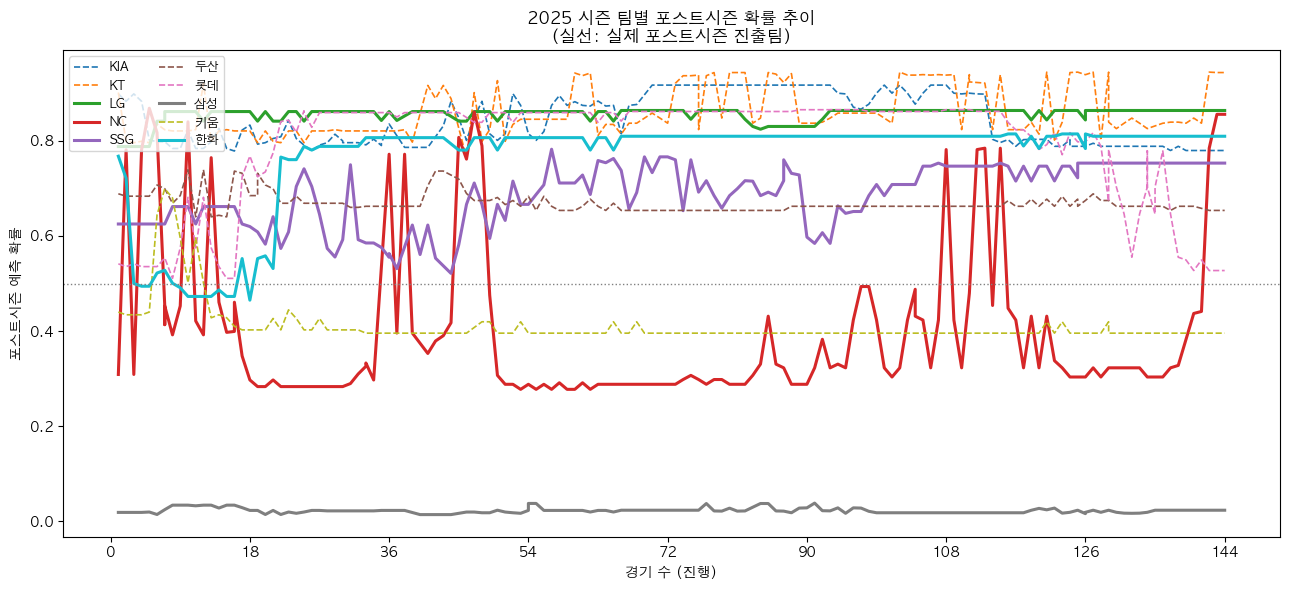

In [5]:
## 시즌 전체 예측 확률 추이 (팀별)
fig, ax = plt.subplots(figsize=(13, 6))

teams = test["team"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(teams)))

for team, color in zip(teams, colors):
    t = test[test["team"] == team].sort_values("games_played_ratio")
    ls = "-" if team in actual_top5 else "--"
    lw = 2.2 if team in actual_top5 else 1.2
    ax.plot(t["games_played_ratio"] * 144, t["prob"], label=team,
            color=color, linestyle=ls, linewidth=lw)

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("경기 수 (진행)")
ax.set_ylabel("포스트시즌 예측 확률")
ax.set_title("2025 시즌 팀별 포스트시즌 확률 추이\n(실선: 실제 포스트시즌 진출팀)")
ax.legend(loc="upper left", ncol=2, fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(18))
plt.tight_layout()
plt.show()

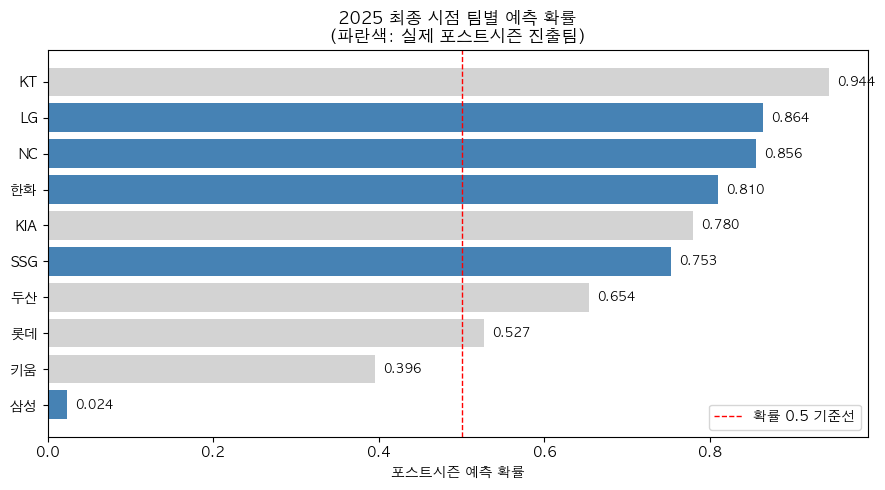

In [6]:
## 최종 시점 예측 확률 순위 (바 차트)
final = test.sort_values("date").groupby("team").last().reset_index()
final = final.sort_values("prob", ascending=True)

colors_bar = ["steelblue" if t in actual_top5 else "lightgray" for t in final["team"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(final["team"], final["prob"], color=colors_bar)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="확률 0.5 기준선")
ax.set_xlabel("포스트시즌 예측 확률")
ax.set_title("2025 최종 시점 팀별 예측 확률\n(파란색: 실제 포스트시즌 진출팀)")
ax.legend()
for bar, val in zip(bars, final["prob"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
## 분류 성능 (전체 2025 일별 행 기준)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== 분류 리포트 (일별 행 기준) ===")
print(classification_report(y_test, y_pred, target_names=["비진출", "포스트시즌"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

=== 분류 리포트 (일별 행 기준) ===
              precision    recall  f1-score   support

         비진출       0.33      0.19      0.24       815
       포스트시즌       0.43      0.61      0.51       815

    accuracy                           0.40      1630
   macro avg       0.38      0.40      0.37      1630
weighted avg       0.38      0.40      0.37      1630

ROC-AUC: 0.3599


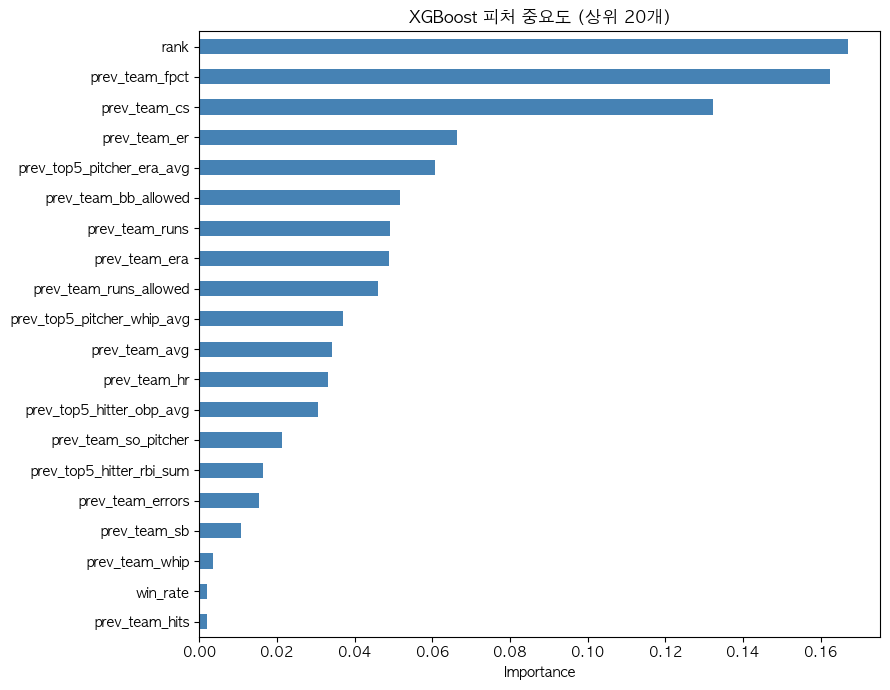

In [8]:
## 피처 중요도 (상위 20개)
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importance = importance.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost 피처 중요도 (상위 20개)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()